In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from chemevo import evolution as evo
import astropy
from astropy.table import Table
from astropy.io import fits
import seaborn as sns
from matplotlib.animation import PillowWriter

params = {
   'axes.labelsize': 15,
   'font.size': 15,
   'legend.fontsize': 14,
   'xtick.minor.visible': True,
   'ytick.minor.visible': True,
   'xtick.labelsize': 15,
   'ytick.labelsize': 15,
   'text.usetex': True, #to use TeX in your labels
   'font.family':'serif',
   'axes.titlesize': 15,
   'xtick.direction': 'in',
   'ytick.direction': 'in',
   'xtick.top': True,
   'ytick.right': True,
   'xtick.major.size': 6,
   'xtick.minor.size': 3,
   'ytick.major.size': 6,
   'ytick.minor.size': 3
   }
rcParams.update(params)

colors = ["#0072B2", "#E69F00", "#009E73", "#D55E00", "#CC79A7", "#F0E442"]
linestyles = ['-', '--', ':', '-.']

In [26]:
import pandas as pd
from astropy.io import fits
from astropy.table import Table

def decode(df):
    """
    Decode DataFrame with byte strings into ordinary strings.
    """
    str_df = df.select_dtypes([object])
    str_df = str_df.stack().str.decode('utf-8').unstack()
    for col in str_df:
        df[col] = str_df[col]
    return df

def fitsrec_to_pandas(fits_rec):
    """
    Convert a FITS_rec object (from astropy.io.fits) to a pandas DataFrame.
    """
    # Convert FITS_rec to astropy Table first
    table = Table(fits_rec)
    
    # Filter out multidimensional columns
    cols = [name for name in table.colnames if len(table[name].shape) <= 1]
    
    # Convert to pandas DataFrame
    df = table[cols].to_pandas()
    
    # Decode byte strings
    df = decode(df)
    
    return df

def compute_binned_median(df, x_col, y_col, n_bins=12):
    """
    Bin df[x_col] into n_bins, then compute median of df[y_col] in each bin,
    and also return the number of points in each bin.

    Returns columns:
    ['x_bin', f'{y_col}_median', 'x_center', 'count']
    """
    
    # Create bins
    x_bins = np.linspace(df[x_col].min(), df[x_col].max(), n_bins + 1)

    # Bin using pd.cut
    x_bin_labels = pd.cut(df[x_col], bins=x_bins, include_lowest=True)

    # Group by bins and compute median AND count
    grouped = df.groupby(x_bin_labels).agg(
        y_median=(y_col, 'median'),
        count=(y_col, 'size')
    ).reset_index()

    # Add x_center using bin midpoint
    grouped['x_center'] = grouped[x_col].apply(lambda interval: interval.mid)

    # Rename bin column
    grouped = grouped.rename(columns={x_col: 'x_bin', 'y_median': f"{y_col}_median"})

    return grouped


In [27]:
with fits.open('../../../data/astroNN_2proc_crossmatch.fits') as hdul:
    astronn_data = hdul[1].data
    twoprocess_data = hdul[2].data

highalpha = pd.read_csv("../../highalpha.csv")
lowalpha = pd.read_csv("../../lowalpha.csv")

data = fitsrec_to_pandas(astronn_data)

data['MN_O'] = data['MN_H'] - data['O_H']
data['FE_O'] = data['FE_H'] - data['O_H']
data['MN_MG'] = data['MN_H'] - data['MG_H']
data['FE_MG'] = data['FE_H'] - data['MG_H']
data['MG_FE'] = data['MG_H'] - data['FE_H']
data['MN_FE'] = data['MN_H'] - data['FE_H']

pos_FE_H = data[(data['FE_H'] > 0)]
neg_FE_H = data[(data['FE_H'] < 0)]
data_high_alpha = pd.concat([pos_FE_H[(pos_FE_H['MG_FE'] > 0.12)], neg_FE_H[neg_FE_H['MG_FE'] > 0.12 - 0.13 * neg_FE_H['FE_H']]])
data_low_alpha = pd.concat([pos_FE_H[(pos_FE_H['MG_FE'] < 0.12)], neg_FE_H[neg_FE_H['MG_FE'] < 0.12 - 0.13 * neg_FE_H['FE_H']]])

# Create FE_H range arrays
feh_neg = np.linspace(data['FE_H'].min(), 0, 300)  # negative metallicity
feh_pos = np.linspace(0, data['FE_H'].max(), 300)  # positive metallicity

# Compute boundary line
mgfe_neg = 0.12 - 0.13 * feh_neg        # sloped part
mgfe_pos = np.full_like(feh_pos, 0.12)  # flat part at +0.12
feh_line = np.concatenate([feh_neg, feh_pos])
mgfe_line = np.concatenate([mgfe_neg, mgfe_pos])
mgh_line = mgfe_line + feh_line
femg_line = feh_line - mgh_line

data_low_alpha = data_low_alpha[(data_low_alpha['galz'] < 2) & (data_low_alpha['galz'] > -2) &
                                (data_low_alpha['galr'] < 15) & (data_low_alpha['galr'] > 3)]

data_high_alpha = data_high_alpha[(data_high_alpha['galz'] < 2) & (data_high_alpha['galz'] > -2) &
                                (data_high_alpha['galr'] < 15) & (data_high_alpha['galr'] > 3)]

mnmg_high = compute_binned_median(data_high_alpha, x_col='MG_H', y_col='MN_MG', n_bins=20)
mnmg_low = compute_binned_median(data_low_alpha, x_col='MG_H', y_col='MN_MG', n_bins=20)
femg_high = compute_binned_median(data_high_alpha, x_col='MG_H', y_col='FE_MG', n_bins=20)
femg_low = compute_binned_median(data_low_alpha, x_col='MG_H', y_col='FE_MG', n_bins=20)

mnmg_high = mnmg_high[mnmg_high['count'] >= 100]
mnmg_low  = mnmg_low[mnmg_low['count']  >= 100]
femg_high = femg_high[femg_high['count'] >= 100]
femg_low  = femg_low[femg_low['count']  >= 100]

data_high_alpha['high_low_alpha'] = "high"
data_low_alpha['high_low_alpha'] = "low"
data_high_alpha['color'] = "hotpink"
data_low_alpha['color'] = "cornflowerblue"

data_all = pd.concat([data_high_alpha, data_low_alpha], ignore_index=True)

data_all = data_all[data_all['zmax'] < 5]

/var/folders/g0/fl404sj151l2v9xcdkjz9fq80000gn/T/ipykernel_83381/3137802370.py:49: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(x_bin_labels).agg(
/var/folders/g0/fl404sj151l2v9xcdkjz9fq80000gn/T/ipykernel_83381/3137802370.py:49: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(x_bin_labels).agg(
/var/folders/g0/fl404sj151l2v9xcdkjz9fq80000gn/T/ipykernel_83381/3137802370.py:49: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the 

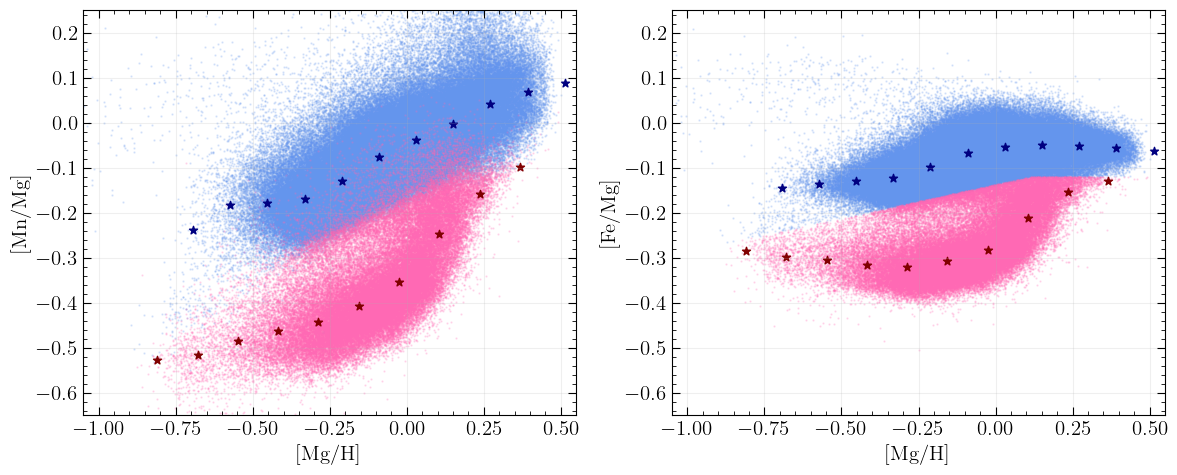

In [28]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(data_low_alpha['MG_H'], data_low_alpha['MN_MG'], alpha = 0.2, color = 'cornflowerblue', s = 0.5)
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['MN_MG'], alpha = 0.2, color = 'hotpink', s = 0.5)


plt.scatter(mnmg_low['x_center'], mnmg_low['MN_MG_median'], marker='*', color = 'navy')
plt.scatter(mnmg_high['x_center'], mnmg_high['MN_MG_median'], marker='*', color = 'maroon')

plt.grid('True', alpha = 0.2)

plt.ylim(-0.65,0.25)
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
plt.xlim(-1.05,0.55)


plt.subplot(1,2,2)
plt.scatter(data_low_alpha['MG_H'], data_low_alpha['FE_MG'], alpha = 0.2, color = 'cornflowerblue', s = 0.5)
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['FE_MG'], alpha = 0.2, color = 'hotpink', s = 0.5)


plt.scatter(femg_low['x_center'], femg_low['FE_MG_median'], marker='*', color = 'navy')
plt.scatter(femg_high['x_center'], femg_high['FE_MG_median'], marker='*', color = 'maroon')

plt.grid('True', alpha = 0.2)
plt.xlabel('[Mg/H]')
plt.ylabel('[Fe/Mg]')
plt.ylim(-0.65,0.25)
plt.xlim(-1.05,0.55)
plt.tight_layout()

In [29]:
mg_h_big_bin_edges = np.arange(-1.0, 1.0, 0.2) 
data_all['MG_H_bin'] = pd.cut(data_all['MG_H'], bins = mg_h_big_bin_edges, right=False, labels=False)

xs = np.linspace(-1, 1, 100)

def downsample(df, N):
    if len(df) > N:
        return df.sample(N, random_state=42)   # random subset of N
    else:
        return df
    
t_array = np.linspace(0.0001,14,int(1e3))
dt = t_array[1] - t_array[0]

In [30]:
m_g_array_const = np.ones(len(t_array))
tau_sfh = 6 #Gyrs
m_g_array_exp = 1 * np.exp(-t_array/tau_sfh)

etas = [0, 0.5, 1]
tau_stars = [0.5, 1, 1.5, 2, 2.5, 3, 4, 5, 6]
colors_lines = ['blue', 'orange', 'green', 'red', 'purple', 'teal', 'magenta', 'brown', 'navy', 'maroon']
colors_dots = ['greenyellow', 'cyan', 'orange', 'blue', 'red', 'yellow', 'green', 'gray', 'peru', 'navy']

tau_stars_2024 = [0.6, 2.0, 6.0]
etas_2024 = [0, 0.6, 1.0]

def rise_fall(t, tau_1, tau_2):
    return 1 * (1 - np.exp(-t/tau_1)) * np.exp(-t/tau_2)

tau_1s = [2, 5, 5]
tau_2s = [6, 10, 20]
sfr_1 = rise_fall(t_array, tau_1s[0], tau_2s[0])
sfr_2 = rise_fall(t_array, tau_1s[1], tau_2s[1])
sfr_3 = rise_fall(t_array, tau_1s[2], tau_2s[2])
mask_1 = t_array > 6
sfr_1[mask_1] = 1e-10

# Normalize each SFR so integral over time equals 1
sfr_1 /= np.trapezoid(sfr_1, t_array)
sfr_2 /= np.trapezoid(sfr_2, t_array)
sfr_3 /= np.trapezoid(sfr_3, t_array)

sfrs = [sfr_1, sfr_2, sfr_3]


gals_taustar_eta0 = []
gals_taustar_eta1 = []
gals_taustar_eta2 = []

#gals_taustar_sfrconst = []
gals_taustar_sfrexp = []
gals_taustar_sfr1 = []
gals_taustar_sfr2 = []
gals_taustar_sfr3 = []


gals_eta = []
gals_sfr = []


for i in range(len(tau_stars)):
    gals_taustar_eta0.append(evo.Galaxy(t_array=t_array, m_g_array=m_g_array_const, tau_star=tau_stars[i], eta=etas[0]))

for i in range(len(tau_stars)):
    gals_taustar_eta1.append(evo.Galaxy(t_array=t_array, m_g_array=m_g_array_const, tau_star=tau_stars[i], eta=etas[1]))

for i in range(len(tau_stars)):
    gals_taustar_eta2.append(evo.Galaxy(t_array=t_array, m_g_array=m_g_array_const, tau_star=tau_stars[i], eta=etas[2]))



for i in range(len(tau_stars)):
    gals_taustar_sfrexp.append(evo.Galaxy(t_array=t_array, m_g_array=m_g_array_exp, tau_star=tau_stars[i], eta=etas[0]))

for i in range(len(tau_stars)):
    gals_taustar_sfr1.append(evo.Galaxy(t_array=t_array, m_g_array=sfrs[0], tau_star=tau_stars[i], eta=etas[0]))

for i in range(len(tau_stars)):
    gals_taustar_sfr2.append(evo.Galaxy(t_array=t_array, m_g_array=sfrs[1], tau_star=tau_stars[i], eta=etas[0]))

for i in range(len(tau_stars)):
    gals_taustar_sfr3.append(evo.Galaxy(t_array=t_array, m_g_array=sfrs[2], tau_star=tau_stars[i], eta=etas[0]))



for j in range(len(etas)):
    gals_eta.append(evo.Galaxy(t_array=t_array, m_g_array=m_g_array_const, tau_star=1, eta=etas[j]))

for k in range(len(sfrs)):
    gals_sfr.append(evo.Galaxy(t_array=t_array, m_g_array=sfrs[k], tau_star=1, eta=0))

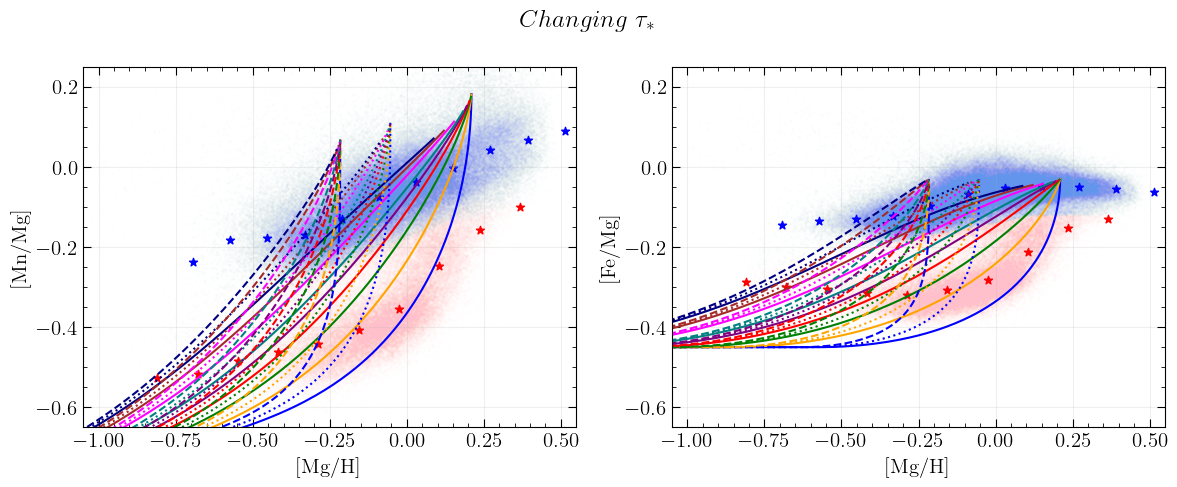

In [31]:
fig = plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(data_low_alpha['MG_H'], data_low_alpha['MN_MG'], alpha = 0.01, color = 'cornflowerblue', s = 0.5)
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['MN_MG'], alpha = 0.01, color = 'pink', s = 0.5)
plt.scatter(mnmg_low['x_center'], mnmg_low['MN_MG_median'], marker='*', color = 'blue')
plt.scatter(mnmg_high['x_center'], mnmg_high['MN_MG_median'], marker='*', color = 'red')

for i in range(len(gals_taustar_eta0)):
    gal = gals_taustar_eta0[i]
    plt.plot(gal.O_H, gal.Mn_O, label = 'Mn, default met dep', color = colors_lines[i], linestyle='-')

for i in range(len(gals_taustar_eta1)):
    gal = gals_taustar_eta1[i]
    plt.plot(gal.O_H, gal.Mn_O, label = 'Mn, default met dep', color = colors_lines[i], linestyle=':')


for i in range(len(gals_taustar_eta2)):
    gal = gals_taustar_eta2[i]
    plt.plot(gal.O_H, gal.Mn_O, label = 'Mn, default met dep', color = colors_lines[i], linestyle='--')



#fig.legend(loc="upper right", bbox_to_anchor=(0.5, 1.05), ncol=3)
plt.grid('True', alpha = 0.2)
plt.ylim(-0.65,0.25)
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
plt.xlim(-1.05,0.55)


plt.subplot(1,2,2)
plt.scatter(data_low_alpha['MG_H'], data_low_alpha['FE_MG'], alpha = 0.01, color = 'cornflowerblue', s = 0.5)
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['FE_MG'], alpha = 0.01, color = 'pink', s = 0.5)
plt.scatter(femg_low['x_center'], femg_low['FE_MG_median'], marker='*', color = 'blue')
plt.scatter(femg_high['x_center'], femg_high['FE_MG_median'], marker='*', color = 'red')

for i in range(len(gals_taustar_eta0)):
    gal = gals_taustar_eta0[i]
    plt.plot(gal.O_H, gal.Fe_O, label = rf'const SFR, $\tau_* = {gal.tau_star_arr[0]} , \eta = {gal.eta_arr[0]} $', color = colors_lines[i])

for i in range(len(gals_taustar_eta1)):
    gal = gals_taustar_eta1[i]
    plt.plot(gal.O_H, gal.Fe_O, label = rf'const SFR, $\tau_* = {gal.tau_star_arr[0]} , \eta = {gal.eta_arr[0]} $', color = colors_lines[i], linestyle=':')


for i in range(len(gals_taustar_eta2)):
    gal = gals_taustar_eta2[i]
    plt.plot(gal.O_H, gal.Fe_O, label = rf'const SFR, $\tau_* = {gal.tau_star_arr[0]} , \eta = {gal.eta_arr[0]} $', color = colors_lines[i], linestyle='--')


plt.grid('True', alpha = 0.2)
plt.xlabel('[Mg/H]')
plt.ylabel('[Fe/Mg]')
plt.ylim(-0.65,0.25)
plt.xlim(-1.05,0.55)

#plt.legend(bbox_to_anchor=[1, 0.5])

plt.suptitle(r"$Changing \ \tau_*$")
plt.tight_layout()

In [32]:
data_all['MG_H_big_bin'] = pd.cut(data_all['MG_H'], bins = mg_h_big_bin_edges, right=False, labels=False)
colors_big_bins = ['brown', 'black', 'blue', 'green', 'hotpink', 'orange', 'red', 'turquoise', 'purple']

mg_h_big_bin_centers = mg_h_big_bin_centers = 0.5 * (mg_h_big_bin_edges[:-1] + mg_h_big_bin_edges[1:])


gals_end_points_taustar_eta0 = []

#eta0

for bin_cent in mg_h_big_bin_centers:
    end_points_in_this_bin = []
    for gal in gals_taustar_eta0:
        o_h = gal.O_H
        for indx in range(len(o_h)):
            o_h_at_time = o_h[indx]
            if o_h_at_time > bin_cent:
                end_points_in_this_bin.append(indx)
                break

    gals_end_points_taustar_eta0.append(np.array(end_points_in_this_bin))


#eta1

gals_end_points_taustar_eta1 = []
for bin_cent in mg_h_big_bin_centers:
    end_points_in_this_bin = []
    for gal in gals_taustar_eta1:
        o_h = gal.O_H
        for indx in range(len(o_h)):
            o_h_at_time = o_h[indx]
            if o_h_at_time > bin_cent:
                end_points_in_this_bin.append(indx)
                break

    gals_end_points_taustar_eta1.append(np.array(end_points_in_this_bin))

#eta2


gals_end_points_taustar_eta2 = []
for bin_cent in mg_h_big_bin_centers:
    end_points_in_this_bin = []
    for gal in gals_taustar_eta2:
        o_h = gal.O_H
        for indx in range(len(o_h)):
            o_h_at_time = o_h[indx]
            if o_h_at_time > bin_cent:
                end_points_in_this_bin.append(indx)
                break

    gals_end_points_taustar_eta2.append(np.array(end_points_in_this_bin))

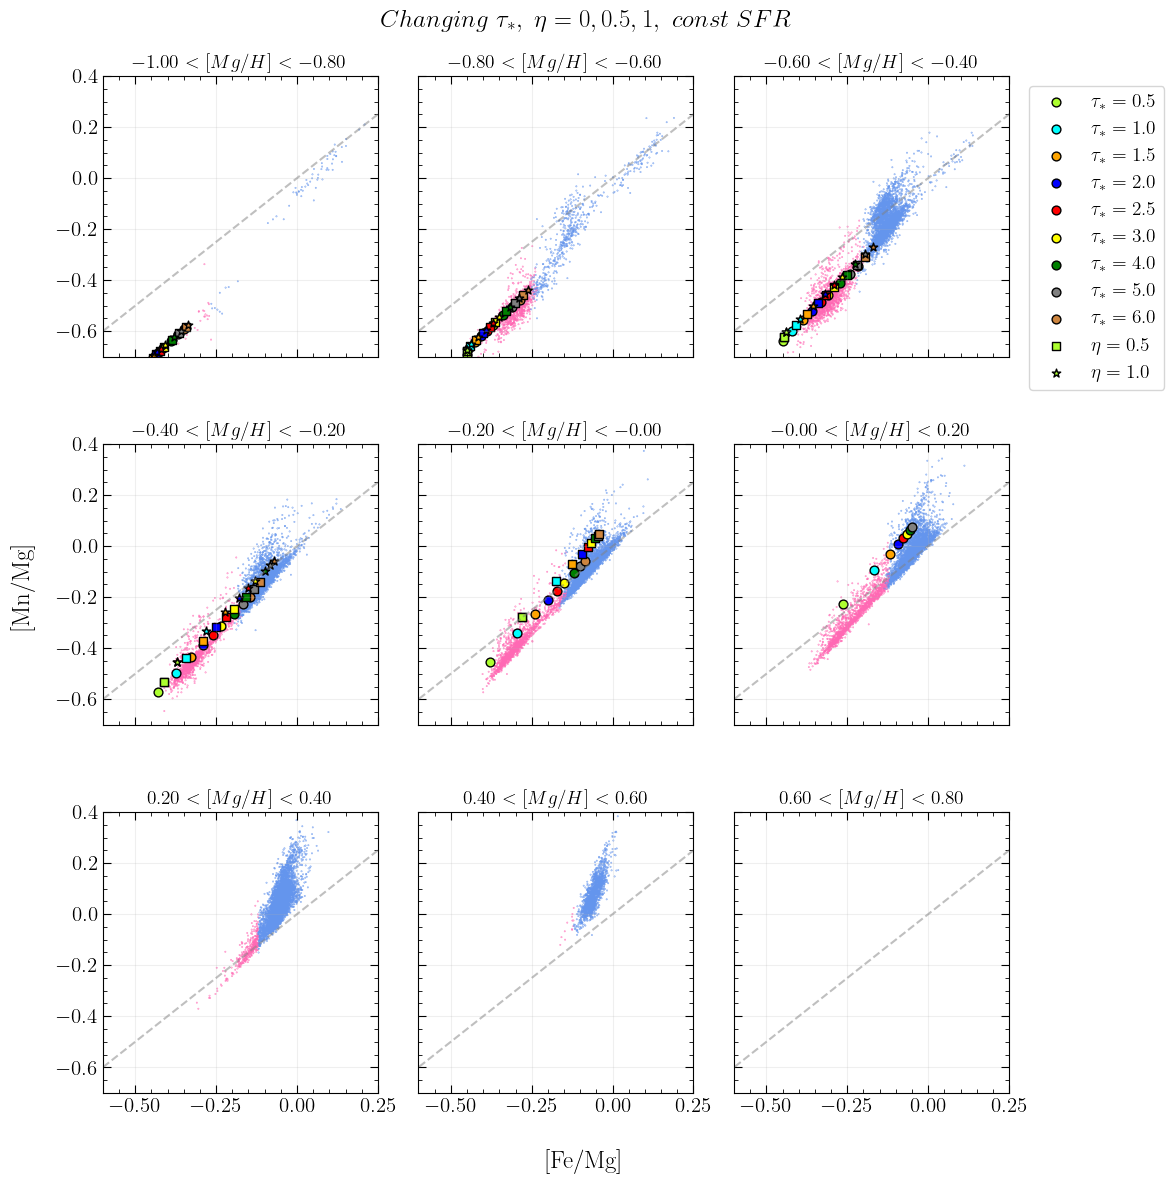

In [33]:
fig, axes = plt.subplots(3, 3, figsize=(12, 12), sharex=True, sharey=True)
axes = axes.flatten()

for i in range(len(mg_h_big_bin_centers)):
    ax = axes[i]
    df_to_plot = data_all[data_all['MG_H_big_bin'] == i]
    df_to_plot = downsample(df_to_plot, 5000)
    ax.scatter(df_to_plot['FE_MG'], df_to_plot['MN_MG'], s=0.1, color=df_to_plot['color'])
    xs = np.linspace(-1, 1, 100)
    ax.plot(xs, xs, linestyle = '--', alpha = 0.5, color = 'gray')

    gal_end_points_this_bin = gals_end_points_taustar_eta0[i]
    for gal_n in range(len(gal_end_points_this_bin)):
        gal_temp = gals_taustar_eta0[gal_n]
        single_indx = gal_end_points_this_bin[gal_n] #indexes of the end points for galaxy n
        ax.scatter(gal_temp.Fe_Mg[single_indx], gal_temp.Mn_Mg[single_indx], s = 40, edgecolors='black', label = rf'$\tau_* = {gal_temp.tau_star_arr[0]}$',
                   color = colors_dots[gal_n])
        
    gal_end_points_this_bin = gals_end_points_taustar_eta1[i]
    for gal_n in range(len(gal_end_points_this_bin)):
        gal_temp = gals_taustar_eta1[gal_n]
        single_indx = gal_end_points_this_bin[gal_n] #indexes of the end points for galaxy n
        if gal_n == 0:
            ax.scatter(gal_temp.Fe_Mg[single_indx], gal_temp.Mn_Mg[single_indx], s = 40, edgecolors='black', label = rf'$\eta = {gal_temp.eta_arr[0]}$',
                   color = colors_dots[gal_n], marker='s')
            
        ax.scatter(gal_temp.Fe_Mg[single_indx], gal_temp.Mn_Mg[single_indx], s = 40, edgecolors='black',
                   color = colors_dots[gal_n], marker='s')
        
    gal_end_points_this_bin = gals_end_points_taustar_eta2[i]
    for gal_n in range(len(gal_end_points_this_bin)):
        gal_temp = gals_taustar_eta2[gal_n]
        single_indx = gal_end_points_this_bin[gal_n] #indexes of the end points for galaxy n
        if gal_n == 0:
            ax.scatter(gal_temp.Fe_Mg[single_indx], gal_temp.Mn_Mg[single_indx], s = 40, edgecolors='black', label = rf'$\eta = {gal_temp.eta_arr[0]}$',
                   color = colors_dots[gal_n], marker='*')
            
        ax.scatter(gal_temp.Fe_Mg[single_indx], gal_temp.Mn_Mg[single_indx], s = 40, edgecolors='black',
                   color = colors_dots[gal_n], marker='*')

    if i == 2:
        ax.legend(loc='upper right',bbox_to_anchor=(1.6, 1.0))
    
    ax.set_title(rf'${mg_h_big_bin_edges[i]:.2f} < [Mg/H] < {mg_h_big_bin_edges[i+1]:.2f}$',fontsize=14)

    ax.grid(True, alpha=0.2)
    ax.set_xlim(-0.60, 0.25)
    ax.set_ylim(-0.70, 0.40)

fig.supxlabel('[Fe/Mg]')
fig.supylabel('[Mn/Mg]')
fig.suptitle(r"$Changing \ \tau_*, \ \eta = 0, 0.5, 1, \ const\ SFR$")
plt.tight_layout()
#plt.savefig("plots/MN_MG_vs_FE_MG_subplots_big_bins_black_blue.png", dpi=300)
plt.show()


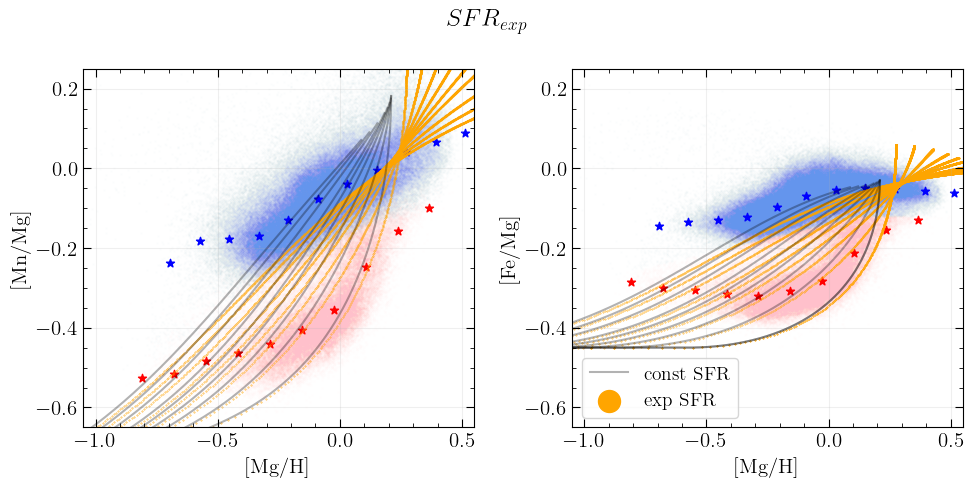

In [34]:
fig = plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.scatter(data_low_alpha['MG_H'], data_low_alpha['MN_MG'], alpha = 0.01, color = 'cornflowerblue', s = 0.5)
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['MN_MG'], alpha = 0.01, color = 'pink', s = 0.5)
plt.scatter(mnmg_low['x_center'], mnmg_low['MN_MG_median'], marker='*', color = 'blue')
plt.scatter(mnmg_high['x_center'], mnmg_high['MN_MG_median'], marker='*', color = 'red')

for i in range(len(gals_taustar_eta0)):
    gal = gals_taustar_eta0[i]
    plt.plot(gal.O_H, gal.Mn_O, label = 'Mn, default met dep', color = 'black', linestyle='-', alpha = 0.3)

for i in range(len(gals_taustar_sfrexp)):
    gal = gals_taustar_sfrexp[i]
    plt.scatter(gal.O_H, gal.Mn_O, color = 'orange', s = 0.1)


#fig.legend(loc="upper right", bbox_to_anchor=(0.5, 1.05), ncol=3)
plt.grid('True', alpha = 0.2)
plt.ylim(-0.65,0.25)
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
plt.xlim(-1.05,0.55)


plt.subplot(1,2,2)
plt.scatter(data_low_alpha['MG_H'], data_low_alpha['FE_MG'], alpha = 0.01, color = 'cornflowerblue', s = 0.5)
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['FE_MG'], alpha = 0.01, color = 'pink', s = 0.5)
plt.scatter(femg_low['x_center'], femg_low['FE_MG_median'], marker='*', color = 'blue')
plt.scatter(femg_high['x_center'], femg_high['FE_MG_median'], marker='*', color = 'red')

for i in range(len(gals_taustar_eta0)):
    gal = gals_taustar_eta0[i]
    if i == 0:
        plt.plot(gal.O_H, gal.Fe_O, label = rf'const SFR', color = 'black', alpha = 0.3)
    
    plt.plot(gal.O_H, gal.Fe_O, color = 'black', alpha = 0.3)

for i in range(len(gals_taustar_sfrexp)):
    gal = gals_taustar_sfrexp[i]
    if i == 0:
        plt.scatter(gal.O_H, gal.Fe_O, color = 'orange', s = 0.1, label = 'exp SFR')
    plt.scatter(gal.O_H, gal.Fe_O, color = 'orange', s = 0.1)

plt.legend(markerscale=50)
plt.grid('True', alpha = 0.2)
plt.xlabel('[Mg/H]')
plt.ylabel('[Fe/Mg]')
plt.ylim(-0.65,0.25)
plt.xlim(-1.05,0.55)

#plt.legend(bbox_to_anchor=[1, 0.5])

plt.suptitle(r"$SFR_{exp}$")
plt.tight_layout()

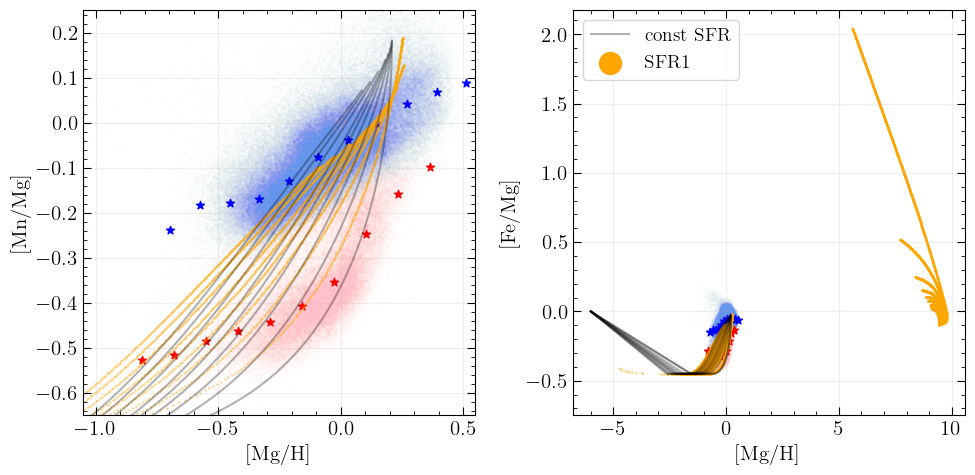

In [35]:
fig = plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.scatter(data_low_alpha['MG_H'], data_low_alpha['MN_MG'], alpha = 0.01, color = 'cornflowerblue', s = 0.5)
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['MN_MG'], alpha = 0.01, color = 'pink', s = 0.5)
plt.scatter(mnmg_low['x_center'], mnmg_low['MN_MG_median'], marker='*', color = 'blue')
plt.scatter(mnmg_high['x_center'], mnmg_high['MN_MG_median'], marker='*', color = 'red')

for i in range(len(gals_taustar_eta0)):
    gal = gals_taustar_eta0[i]
    plt.plot(gal.O_H, gal.Mn_O, label = 'Mn, default met dep', color = 'black', linestyle='-', alpha = 0.3)

for i in range(len(gals_taustar_sfr1)):
    gal = gals_taustar_sfr1[i]
    plt.scatter(gal.O_H, gal.Mn_O, color = 'orange', s = 0.1)


#fig.legend(loc="upper right", bbox_to_anchor=(0.5, 1.05), ncol=3)
plt.grid('True', alpha = 0.2)
plt.ylim(-0.65,0.25)
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
plt.xlim(-1.05,0.55)


plt.subplot(1,2,2)
plt.scatter(data_low_alpha['MG_H'], data_low_alpha['FE_MG'], alpha = 0.01, color = 'cornflowerblue', s = 0.5)
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['FE_MG'], alpha = 0.01, color = 'pink', s = 0.5)
plt.scatter(femg_low['x_center'], femg_low['FE_MG_median'], marker='*', color = 'blue')
plt.scatter(femg_high['x_center'], femg_high['FE_MG_median'], marker='*', color = 'red')

for i in range(len(gals_taustar_eta0)):
    gal = gals_taustar_eta0[i]
    if i == 0:
        plt.plot(gal.O_H, gal.Fe_O, label = rf'const SFR', color = 'black', alpha = 0.3)
    
    plt.plot(gal.O_H, gal.Fe_O, color = 'black', alpha = 0.3)

for i in range(len(gals_taustar_sfr1)):
    gal = gals_taustar_sfr1[i]
    if i == 0:
        plt.scatter(gal.O_H, gal.Fe_O, color = 'orange', s = 0.1, label = 'SFR1')
    plt.scatter(gal.O_H, gal.Fe_O, color = 'orange', s = 0.1)

plt.legend(markerscale=50)
plt.grid('True', alpha = 0.2)
plt.xlabel('[Mg/H]')
plt.ylabel('[Fe/Mg]')
#plt.ylim(-0.65,0.25)
#plt.xlim(-1.05,0.55)

#plt.legend(bbox_to_anchor=[1, 0.5])

plt.tight_layout()

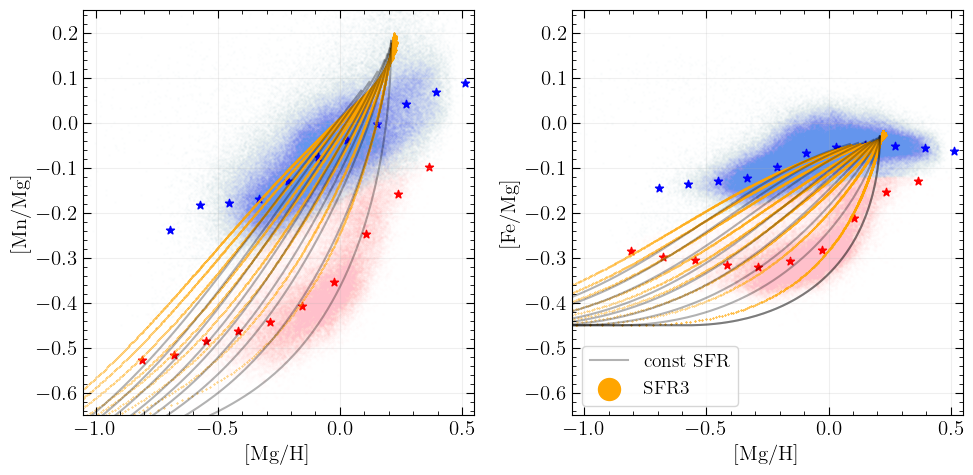

In [36]:
fig = plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.scatter(data_low_alpha['MG_H'], data_low_alpha['MN_MG'], alpha = 0.01, color = 'cornflowerblue', s = 0.5)
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['MN_MG'], alpha = 0.01, color = 'pink', s = 0.5)
plt.scatter(mnmg_low['x_center'], mnmg_low['MN_MG_median'], marker='*', color = 'blue')
plt.scatter(mnmg_high['x_center'], mnmg_high['MN_MG_median'], marker='*', color = 'red')

for i in range(len(gals_taustar_eta0)):
    gal = gals_taustar_eta0[i]
    plt.plot(gal.O_H, gal.Mn_O, label = 'Mn, default met dep', color = 'black', linestyle='-', alpha = 0.3)

for i in range(len(gals_taustar_sfr3)):
    gal = gals_taustar_sfr3[i]
    plt.scatter(gal.O_H, gal.Mn_O, color = 'orange', s = 0.1)


#fig.legend(loc="upper right", bbox_to_anchor=(0.5, 1.05), ncol=3)
plt.grid('True', alpha = 0.2)
plt.ylim(-0.65,0.25)
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
plt.xlim(-1.05,0.55)


plt.subplot(1,2,2)
plt.scatter(data_low_alpha['MG_H'], data_low_alpha['FE_MG'], alpha = 0.01, color = 'cornflowerblue', s = 0.5)
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['FE_MG'], alpha = 0.01, color = 'pink', s = 0.5)
plt.scatter(femg_low['x_center'], femg_low['FE_MG_median'], marker='*', color = 'blue')
plt.scatter(femg_high['x_center'], femg_high['FE_MG_median'], marker='*', color = 'red')

for i in range(len(gals_taustar_eta0)):
    gal = gals_taustar_eta0[i]
    if i == 0:
        plt.plot(gal.O_H, gal.Fe_O, label = rf'const SFR', color = 'black', alpha = 0.3)
    
    plt.plot(gal.O_H, gal.Fe_O, color = 'black', alpha = 0.3)

for i in range(len(gals_taustar_sfr3)):
    gal = gals_taustar_sfr3[i]
    if i == 0:
        plt.scatter(gal.O_H, gal.Fe_O, color = 'orange', s = 0.1, label = 'SFR3')
    plt.scatter(gal.O_H, gal.Fe_O, color = 'orange', s = 0.1)

plt.legend(markerscale=50)
plt.grid('True', alpha = 0.2)
plt.xlabel('[Mg/H]')
plt.ylabel('[Fe/Mg]')
plt.ylim(-0.65,0.25)
plt.xlim(-1.05,0.55)

#plt.legend(bbox_to_anchor=[1, 0.5])

plt.tight_layout()

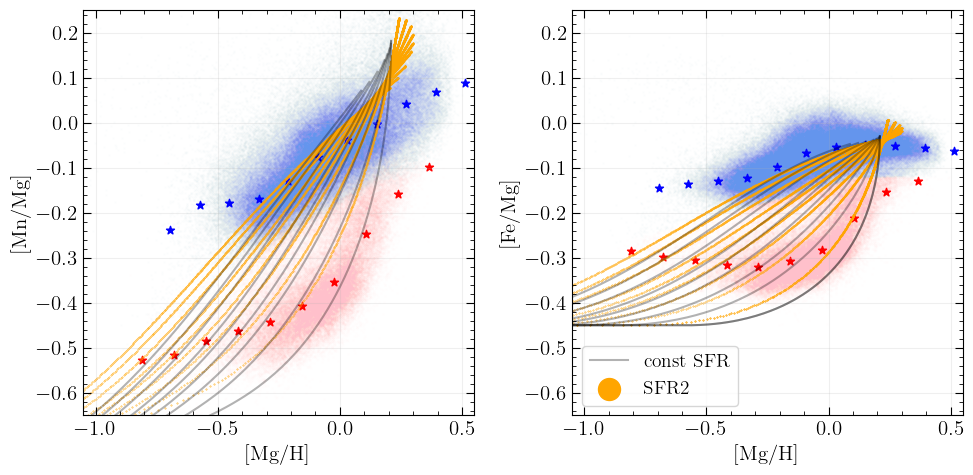

In [37]:
fig = plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.scatter(data_low_alpha['MG_H'], data_low_alpha['MN_MG'], alpha = 0.01, color = 'cornflowerblue', s = 0.5)
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['MN_MG'], alpha = 0.01, color = 'pink', s = 0.5)
plt.scatter(mnmg_low['x_center'], mnmg_low['MN_MG_median'], marker='*', color = 'blue')
plt.scatter(mnmg_high['x_center'], mnmg_high['MN_MG_median'], marker='*', color = 'red')

for i in range(len(gals_taustar_eta0)):
    gal = gals_taustar_eta0[i]
    plt.plot(gal.O_H, gal.Mn_O, label = 'Mn, default met dep', color = 'black', linestyle='-', alpha = 0.3)

for i in range(len(gals_taustar_sfr2)):
    gal = gals_taustar_sfr2[i]
    plt.scatter(gal.O_H, gal.Mn_O, color = 'orange', s = 0.1)


#fig.legend(loc="upper right", bbox_to_anchor=(0.5, 1.05), ncol=3)
plt.grid('True', alpha = 0.2)
plt.ylim(-0.65,0.25)
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
plt.xlim(-1.05,0.55)


plt.subplot(1,2,2)
plt.scatter(data_low_alpha['MG_H'], data_low_alpha['FE_MG'], alpha = 0.01, color = 'cornflowerblue', s = 0.5)
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['FE_MG'], alpha = 0.01, color = 'pink', s = 0.5)
plt.scatter(femg_low['x_center'], femg_low['FE_MG_median'], marker='*', color = 'blue')
plt.scatter(femg_high['x_center'], femg_high['FE_MG_median'], marker='*', color = 'red')

for i in range(len(gals_taustar_eta0)):
    gal = gals_taustar_eta0[i]
    if i == 0:
        plt.plot(gal.O_H, gal.Fe_O, label = rf'const SFR', color = 'black', alpha = 0.3)
    
    plt.plot(gal.O_H, gal.Fe_O, color = 'black', alpha = 0.3)

for i in range(len(gals_taustar_sfr2)):
    gal = gals_taustar_sfr2[i]
    if i == 0:
        plt.scatter(gal.O_H, gal.Fe_O, color = 'orange', s = 0.1, label = 'SFR2')
    plt.scatter(gal.O_H, gal.Fe_O, color = 'orange', s = 0.1)

plt.legend(markerscale=50)
plt.grid('True', alpha = 0.2)
plt.xlabel('[Mg/H]')
plt.ylabel('[Fe/Mg]')
plt.ylim(-0.65,0.25)
plt.xlim(-1.05,0.55)

#plt.legend(bbox_to_anchor=[1, 0.5])

plt.tight_layout()

In [38]:
mg_h_big_bin_edges = np.arange(-1.0, 1.0, 0.2) 
data_all['MG_H_big_bin'] = pd.cut(data_all['MG_H'], bins = mg_h_big_bin_edges, right=False, labels=False)
colors_big_bins = ['brown', 'black', 'blue', 'green', 'hotpink', 'orange', 'red', 'turquoise', 'purple']

mg_h_big_bin_centers = mg_h_big_bin_centers = 0.5 * (mg_h_big_bin_edges[:-1] + mg_h_big_bin_edges[1:])


gals_end_points_taustar_sfrexp = []

#sfrexp

for bin_cent in mg_h_big_bin_centers:
    end_points_in_this_bin = []
    for gal in gals_taustar_sfrexp:
        o_h = gal.O_H
        for indx in range(len(o_h)):
            o_h_at_time = o_h[indx]
            if o_h_at_time > bin_cent:
                end_points_in_this_bin.append(indx)
                break

    gals_end_points_taustar_sfrexp.append(np.array(end_points_in_this_bin))


#sfr1

gals_end_points_taustar_sfr1 = []
for bin_cent in mg_h_big_bin_centers:
    end_points_in_this_bin = []
    for gal in gals_taustar_sfr1:
        o_h = gal.O_H
        for indx in range(len(o_h)):
            o_h_at_time = o_h[indx]
            if o_h_at_time > bin_cent:
                end_points_in_this_bin.append(indx)
                break

    gals_end_points_taustar_sfr1.append(np.array(end_points_in_this_bin))

#sfr2


gals_end_points_taustar_sfr2 = []
for bin_cent in mg_h_big_bin_centers:
    end_points_in_this_bin = []
    for gal in gals_taustar_sfr2:
        o_h = gal.O_H
        for indx in range(len(o_h)):
            o_h_at_time = o_h[indx]
            if o_h_at_time > bin_cent:
                end_points_in_this_bin.append(indx)
                break

    gals_end_points_taustar_sfr2.append(np.array(end_points_in_this_bin))


#sfr3

gals_end_points_taustar_sfr3 = []
for bin_cent in mg_h_big_bin_centers:
    end_points_in_this_bin = []
    for gal in gals_taustar_sfr3:
        o_h = gal.O_H
        for indx in range(len(o_h)):
            o_h_at_time = o_h[indx]
            if o_h_at_time > bin_cent:
                end_points_in_this_bin.append(indx)
                break

    gals_end_points_taustar_sfr3.append(np.array(end_points_in_this_bin))

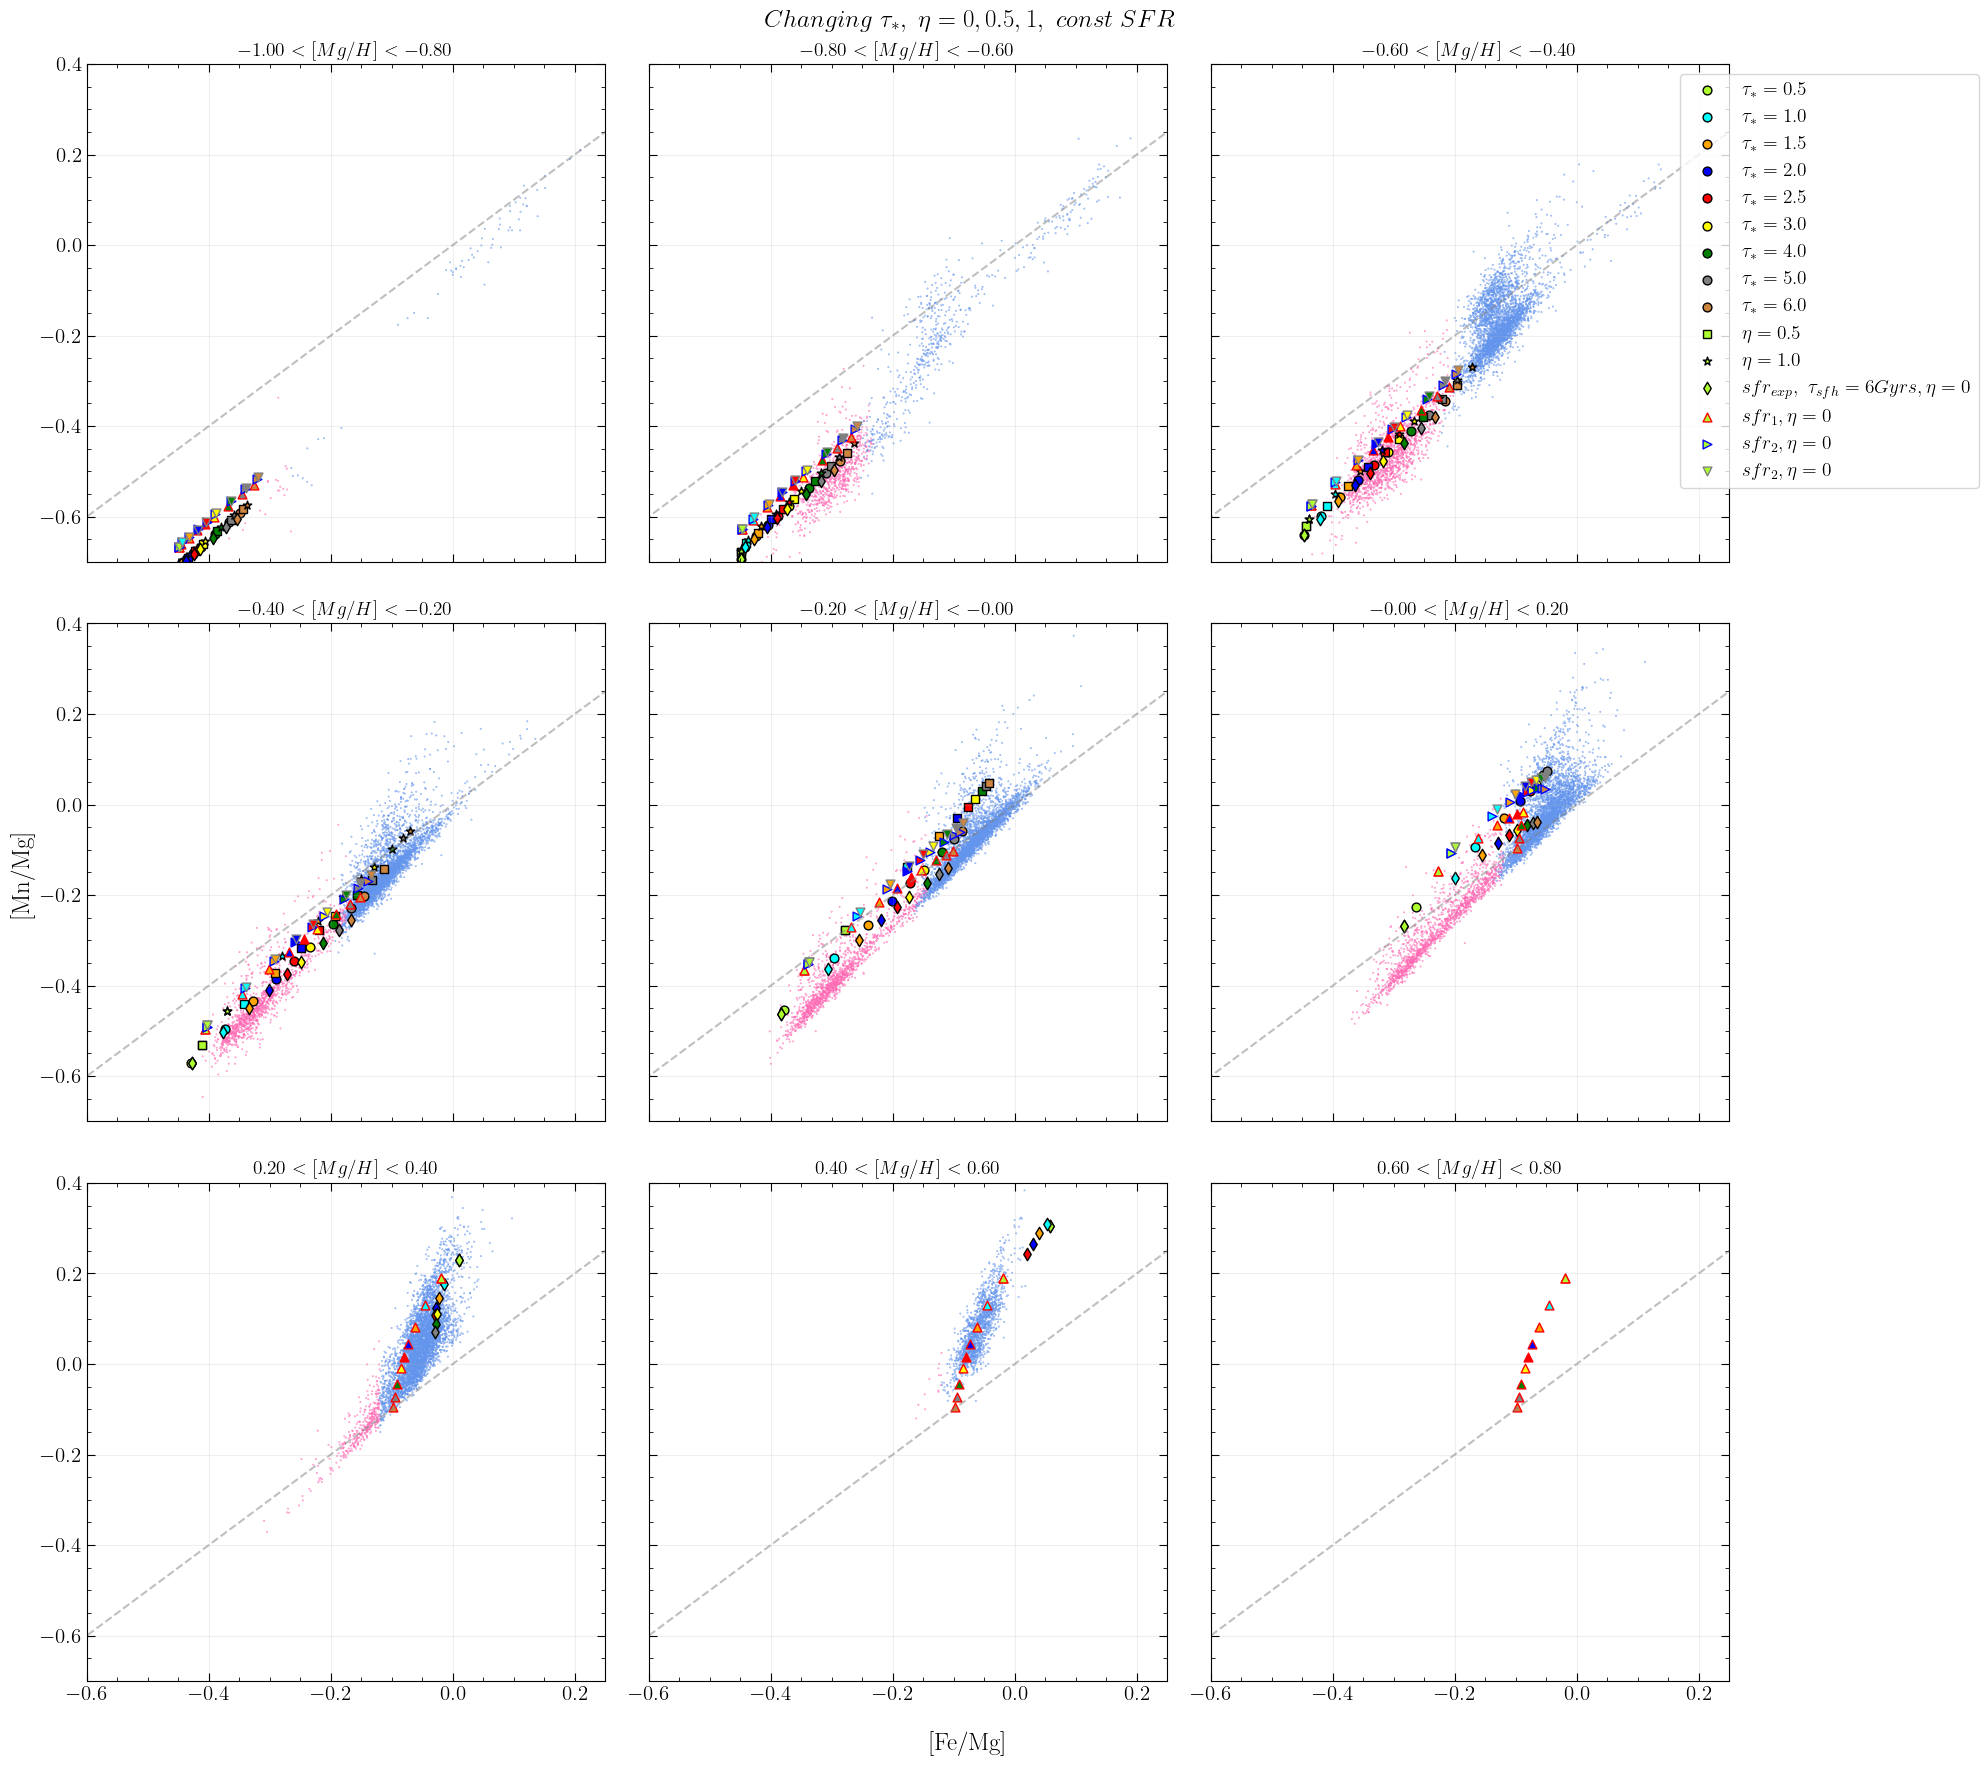

In [39]:
fig, axes = plt.subplots(3, 3, figsize=(20, 18), sharex=True, sharey=True)
axes = axes.flatten()

for i in range(len(mg_h_big_bin_centers)):
    ax = axes[i]
    df_to_plot = data_all[data_all['MG_H_big_bin'] == i]
    df_to_plot = downsample(df_to_plot, 5000)
    ax.scatter(df_to_plot['FE_MG'], df_to_plot['MN_MG'], s=0.1, color=df_to_plot['color'])
    xs = np.linspace(-1, 1, 100)
    ax.plot(xs, xs, linestyle = '--', alpha = 0.5, color = 'gray')

    gal_end_points_this_bin = gals_end_points_taustar_eta0[i]
    for gal_n in range(len(gal_end_points_this_bin)):
        gal_temp = gals_taustar_eta0[gal_n]
        single_indx = gal_end_points_this_bin[gal_n] #indexes of the end points for galaxy n
        ax.scatter(gal_temp.Fe_Mg[single_indx], gal_temp.Mn_Mg[single_indx], s = 40, edgecolors='black', label = rf'$\tau_* = {gal_temp.tau_star_arr[0]}$',
                   color = colors_dots[gal_n])
        
    gal_end_points_this_bin = gals_end_points_taustar_eta1[i]
    for gal_n in range(len(gal_end_points_this_bin)):
        gal_temp = gals_taustar_eta1[gal_n]
        single_indx = gal_end_points_this_bin[gal_n] #indexes of the end points for galaxy n
        if gal_n == 0:
            ax.scatter(gal_temp.Fe_Mg[single_indx], gal_temp.Mn_Mg[single_indx], s = 40, edgecolors='black', label = rf'$\eta = {gal_temp.eta_arr[0]}$',
                   color = colors_dots[gal_n], marker='s')
            
        ax.scatter(gal_temp.Fe_Mg[single_indx], gal_temp.Mn_Mg[single_indx], s = 40, edgecolors='black',
                   color = colors_dots[gal_n], marker='s')
        
    gal_end_points_this_bin = gals_end_points_taustar_eta2[i]
    for gal_n in range(len(gal_end_points_this_bin)):
        gal_temp = gals_taustar_eta2[gal_n]
        single_indx = gal_end_points_this_bin[gal_n] #indexes of the end points for galaxy n
        if gal_n == 0:
            ax.scatter(gal_temp.Fe_Mg[single_indx], gal_temp.Mn_Mg[single_indx], s = 40, edgecolors='black', label = rf'$\eta = {gal_temp.eta_arr[0]}$',
                   color = colors_dots[gal_n], marker='*')
            
        ax.scatter(gal_temp.Fe_Mg[single_indx], gal_temp.Mn_Mg[single_indx], s = 40, edgecolors='black',
                   color = colors_dots[gal_n], marker='*')
        

    gal_end_points_this_bin = gals_end_points_taustar_sfrexp[i]
    for gal_n in range(len(gal_end_points_this_bin)):
        gal_temp = gals_taustar_sfrexp[gal_n]
        single_indx = gal_end_points_this_bin[gal_n] #indexes of the end points for galaxy n
        if gal_n == 0:
            ax.scatter(gal_temp.Fe_Mg[single_indx], gal_temp.Mn_Mg[single_indx], s = 40, edgecolors='black', label = r'$sfr_{exp}, \ \tau_{sfh} = 6 Gyrs, \eta = 0$',
                   color = colors_dots[gal_n], marker='d')
            
        ax.scatter(gal_temp.Fe_Mg[single_indx], gal_temp.Mn_Mg[single_indx], s = 40, edgecolors='black',
                   color = colors_dots[gal_n], marker='d')
        

    gal_end_points_this_bin = gals_end_points_taustar_sfr1[i]
    for gal_n in range(len(gal_end_points_this_bin)):
        gal_temp = gals_taustar_sfr1[gal_n]
        single_indx = gal_end_points_this_bin[gal_n] #indexes of the end points for galaxy n
        if gal_n == 0:
            ax.scatter(gal_temp.Fe_Mg[single_indx], gal_temp.Mn_Mg[single_indx], s = 40, edgecolors='red', label = r'$sfr_{1}, \eta = 0$',
                   color = colors_dots[gal_n], marker='^')
            
        ax.scatter(gal_temp.Fe_Mg[single_indx], gal_temp.Mn_Mg[single_indx], s = 40, edgecolors='red',
                   color = colors_dots[gal_n], marker='^')
        
    gal_end_points_this_bin = gals_end_points_taustar_sfr2[i]
    for gal_n in range(len(gal_end_points_this_bin)):
        gal_temp = gals_taustar_sfr2[gal_n]
        single_indx = gal_end_points_this_bin[gal_n] #indexes of the end points for galaxy n
        if gal_n == 0:
            ax.scatter(gal_temp.Fe_Mg[single_indx], gal_temp.Mn_Mg[single_indx], s = 40, edgecolors='blue', label = r'$sfr_{2}, \eta = 0$',
                   color = colors_dots[gal_n], marker='>')
            
        ax.scatter(gal_temp.Fe_Mg[single_indx], gal_temp.Mn_Mg[single_indx], s = 40, edgecolors='blue',
                   color = colors_dots[gal_n], marker='>')
    
    gal_end_points_this_bin = gals_end_points_taustar_sfr3[i]
    for gal_n in range(len(gal_end_points_this_bin)):
        gal_temp = gals_taustar_sfr3[gal_n]
        single_indx = gal_end_points_this_bin[gal_n] #indexes of the end points for galaxy n
        if gal_n == 0:
            ax.scatter(gal_temp.Fe_Mg[single_indx], gal_temp.Mn_Mg[single_indx], s = 40, edgecolors='gray', label = r'$sfr_{2}, \eta = 0$',
                   color = colors_dots[gal_n], marker='v')
            
        ax.scatter(gal_temp.Fe_Mg[single_indx], gal_temp.Mn_Mg[single_indx], s = 40, edgecolors='gray',
                   color = colors_dots[gal_n], marker='v')

    

    if i == 2:
        ax.legend(loc='upper right',bbox_to_anchor=(1.5, 1.0))
    
    ax.set_title(rf'${mg_h_big_bin_edges[i]:.2f} < [Mg/H] < {mg_h_big_bin_edges[i+1]:.2f}$',fontsize=14)

    ax.grid(True, alpha=0.2)
    ax.set_xlim(-0.60, 0.25)
    ax.set_ylim(-0.70, 0.40)

fig.supxlabel('[Fe/Mg]')
fig.supylabel('[Mn/Mg]')
fig.suptitle(r"$Changing \ \tau_*, \ \eta = 0, 0.5, 1, \ const\ SFR$")
plt.tight_layout()
#plt.savefig("plots/MN_MG_vs_FE_MG_subplots_big_bins_black_blue.png", dpi=300)
plt.show()


Text(0, 0.5, 'SFR')

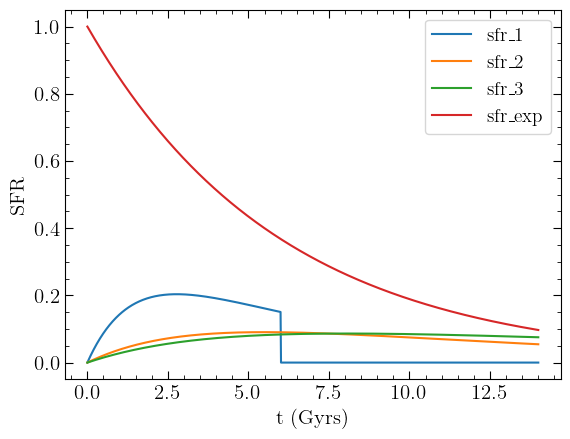

In [40]:
for i in range(len(sfrs)):
    plt.plot(t_array, sfrs[i], label = f'sfr_{i+1}')

plt.plot(t_array, m_g_array_exp, label = r'sfr_{exp}')
plt.legend(loc = 'upper right')
plt.xlabel('t (Gyrs)')
plt.ylabel('SFR')

In [41]:
sfr_1

array([2.15326540e-05, 3.02141252e-03, 5.98639723e-03, 8.91682761e-03,
       1.18130413e-02, 1.46753726e-02, 1.75041530e-02, 2.02997105e-02,
       2.30623703e-02, 2.57924544e-02, 2.84902817e-02, 3.11561683e-02,
       3.37904272e-02, 3.63933683e-02, 3.89652989e-02, 4.15065233e-02,
       4.40173427e-02, 4.64980557e-02, 4.89489581e-02, 5.13703428e-02,
       5.37624999e-02, 5.61257170e-02, 5.84602788e-02, 6.07664672e-02,
       6.30445618e-02, 6.52948392e-02, 6.75175736e-02, 6.97130366e-02,
       7.18814972e-02, 7.40232218e-02, 7.61384744e-02, 7.82275165e-02,
       8.02906070e-02, 8.23280025e-02, 8.43399571e-02, 8.63267226e-02,
       8.82885482e-02, 9.02256811e-02, 9.21383659e-02, 9.40268448e-02,
       9.58913581e-02, 9.77321435e-02, 9.95494365e-02, 1.01343470e-01,
       1.03114477e-01, 1.04862684e-01, 1.06588319e-01, 1.08291606e-01,
       1.09972768e-01, 1.11632026e-01, 1.13269598e-01, 1.14885699e-01,
       1.16480545e-01, 1.18054347e-01, 1.19607315e-01, 1.21139659e-01,
      